# Instructions

The places where you have enter code, to answer the questions, are marked with `# YOUR CODE HERE`.

## Question 1 (6 points)

Given the following QUBO, complete the function `create_bqm` so that it returns the corresponding BQM.

$$- 7x_1 - 2x_2 - 10x_3 - 4x_4 + 5x_1x_2 + 3x_1x_3 + 6x_2x_3 - 8x_3x_4 - 2$$


The function `create_bqm` has

- Input: None
- Returns:
    - A BQM instance


In [15]:
from dimod import BQM
from dimod import BinaryQuadraticModel

def create_bqm():
    # YOUR CODE HERE
    # Define the linear terms
    linear = {
        'x1': -7,
        'x2': -2,
        'x3': -10,
        'x4': -4
    }
    
    # Define the quadratic terms
    quadratic = {
        ('x1', 'x2'): 5,
        ('x1', 'x3'): 3,
        ('x2', 'x3'): 6,
        ('x3', 'x4'): -8
    }
    
    # Create the BQM instance with the offset included
    bqm = BinaryQuadraticModel(linear, quadratic, offset=-2, vartype='BINARY')
    

    
    # Do not modify anything below this line
    return bqm

In [16]:
# You can use this cell to call and check the output of the function

print(create_bqm())

BinaryQuadraticModel({'x1': -7.0, 'x2': -2.0, 'x3': -10.0, 'x4': -4.0}, {('x2', 'x1'): 5.0, ('x3', 'x1'): 3.0, ('x3', 'x2'): 6.0, ('x4', 'x3'): -8.0}, -2.0, 'BINARY')


In [10]:
# hidden tests will be used for grading.

## Question 2 (6 points)

Function `solve_Q` takes as input a matrix representation of a QUBO formulation. Complete the function `solve_Q` so that it returns the solution to the given problem. Use D-Wave's `ExactSolver()`.


The function `solve_Q` has

- Input:
    - Q matrix representation of QUBO as an `numpy.array`.
- Returns:
    - Sample with the lowest energy (first sample of the SampleSet)


In [23]:
from dimod import BQM

def solve_Q(Q):
    # YOUR CODE HERE
     # Convert the Q matrix into a Binary Quadratic Model (BQM)
    bqm = BQM.from_qubo(Q)
    
    # Initialize the ExactSolver
    solver = ExactSolver()
    
    # Solve the BQM
    sampleset = solver.sample(bqm)
    # Do not modify anything below this line
    return sampleset.first

In [24]:
# You can use this cell to call and check the output of the function
import numpy as np
from dimod.reference.samplers import ExactSolver


Q = np.array([[1, 1], [0, 1]])
print(solve_Q(Q))

Sample(sample={0: 0, 1: 0}, energy=0.0, num_occurrences=1)


In [25]:
# hidden tests will be used for grading.

## Question 3 (6 points)

You are given a graph $G$ in the next cell where the nodes are labeled $0,1,\dots,8$. Create a BQM with `SPIN` variables to solve Max-Cut problem for the given graph. Variables should be named with the name of the correspoding node.

The function `max_cut` has

- Input: None 
- Returns:
    - BQM with SPIN variables for graph `G`


EdgeView([(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)])

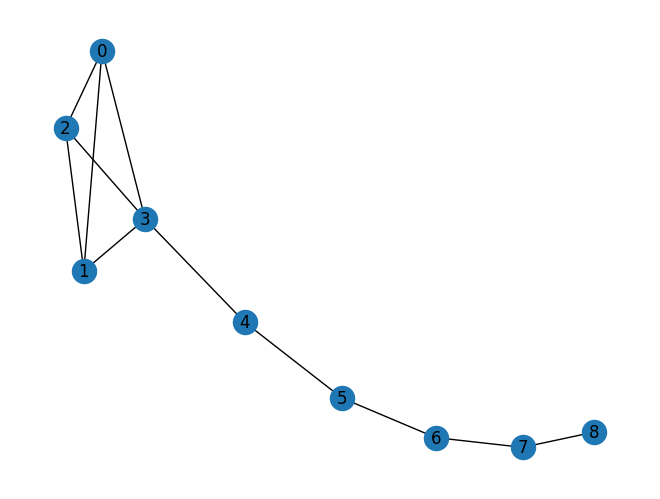

In [9]:
import networkx as nx

G = nx.lollipop_graph(4, 5)
nx.draw(G, with_labels=True)
G.edges

In [10]:
from dimod import BQM
from collections import defaultdict

def max_cut():
    # YOUR CODE HERE
    h = defaultdict(int)
    J = defaultdict(int)

    for i, j in G.edges:
     J[(i, j)] += 1

    print(f"h = {h}")
    print(f"J = {J}")
    bqm = BQM.from_ising(h, J)
    # Do not modify anything below this line
    return bqm

In [11]:
# You can use this cell to call and check the output of the function
print(max_cut())

h = defaultdict(<class 'int'>, {})
J = defaultdict(<class 'int'>, {(0, 1): 1, (0, 2): 1, (0, 3): 1, (1, 2): 1, (1, 3): 1, (2, 3): 1, (3, 4): 1, (4, 5): 1, (5, 6): 1, (6, 7): 1, (7, 8): 1})
BinaryQuadraticModel({0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0}, {(1, 0): 1.0, (2, 0): 1.0, (2, 1): 1.0, (3, 0): 1.0, (3, 1): 1.0, (3, 2): 1.0, (4, 3): 1.0, (5, 4): 1.0, (6, 5): 1.0, (7, 6): 1.0, (8, 7): 1.0}, 0.0, 'SPIN')


In [12]:
# hidden tests will be used for grading.
# If this cell results in an error, your implementation is incorrect